# Logistic Regression Experiments
This notebook is a lightweight sandbox for primitive test runs.

Run cells in order from top to bottom.

In [81]:
import os
import numpy as np
import pandas as pd
import csv

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from preprocessing import build_raw_dataset_nlp

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

# Data root in this repo
BASE_DIR = "datasets_full.csv/datasets_full.csv"
USERS_FILE = "users.csv"
TWEETS_FILE = "tweets.csv"

DATASETS = {
    "genuine_accounts.csv": 0,
    "fake_followers.csv": 1,
    "social_spambots_1.csv": 1,
    "social_spambots_2.csv": 1,
    "social_spambots_3.csv": 1,
    "traditional_spambots_1.csv": 1,
    "traditional_spambots_2.csv": 1,
    "traditional_spambots_3.csv": 1,
    "traditional_spambots_4.csv": 1,
}

TEXT_COLUMN = "text"

USER_FEATURES = [
    "statuses_count", "followers_count", "friends_count",
    "favourites_count", "listed_count", "default_profile",
    "default_profile_image", "verified"
]

TWEET_FEATURES = [
   "reply_count", "favorite_count", "num_urls", "num_mentions"
]

print("Dataset root:", BASE_DIR)
print("Files configured:", len(DATASETS))

Dataset root: datasets_full.csv/datasets_full.csv
Files configured: 9


In [82]:
# Block 1: Data loading (full configured datasets)
raw = build_raw_dataset_nlp(
    DATASETS,
    BASE_DIR,
    TWEET_FEATURES,
    TWEETS_FILE
)

Loaded genuine_accounts.csv: 3,474 rows
Loaded fake_followers.csv: 3,351 rows
Loaded social_spambots_1.csv: 991 rows
Loaded social_spambots_2.csv: 3,457 rows
Loaded social_spambots_3.csv: 464 rows
Loaded traditional_spambots_1.csv: 1,000 rows
Loaded traditional_spambots_2.csv: 100 rows
Loaded traditional_spambots_3.csv: 403 rows
Loaded traditional_spambots_4.csv: 1,128 rows

Total rows loaded: 14,368


In [83]:
# Block 2: Slicing and preprocessing
available_numeric = [c for c in USER_FEATURES if c in raw.columns]
if not available_numeric:
    raise ValueError("No numeric feature columns found in raw data.")

X_num = raw[available_numeric].copy()
X_num = X_num.apply(pd.to_numeric, errors="coerce")

tweet_features = [c for c in TWEET_FEATURES if c in raw.columns]
X_num = pd.concat([X_num, raw[tweet_features]], axis=1)

X_num = X_num.fillna(0)

text_data = raw[TEXT_COLUMN].fillna("")

tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    stop_words="english",
    max_df=0.85,
    min_df=5
)

X_text = tfidf.fit_transform(text_data)

X = hstack([X_num.values, X_text])
    
# print(X.columns) 
# print(X.shape)

print(raw.columns.tolist())
print(TEXT_COLUMN)

y = raw["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class balance:\n", y.value_counts(dropna=False))

['id', 'name', 'screen_name', 'statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'url', 'lang', 'time_zone', 'location', 'default_profile', 'default_profile_image', 'geo_enabled', 'profile_image_url', 'profile_banner_url', 'profile_use_background_image', 'profile_background_image_url_https', 'profile_text_color', 'profile_image_url_https', 'profile_sidebar_border_color', 'profile_background_tile', 'profile_sidebar_fill_color', 'profile_background_image_url', 'profile_background_color', 'profile_link_color', 'utc_offset', 'is_translator', 'follow_request_sent', 'protected', 'verified', 'notifications', 'description', 'contributors_enabled', 'following', 'created_at', 'timestamp', 'crawled_at', 'updated', 'test_set_1', 'test_set_2', 'label', 'source_file', 'user_id', 'reply_count', 'favorite_count', 'num_urls', 'num_mentions', 'text']
text
Train shape: (11494, 2012)
Test shape: (2874, 2012)
Class balance:
 label
1    10894
0     3474
Name: count, dt

In [84]:
# Block 3: Training
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_scaled, y_train)

print("Training complete.")
print("Model intercept:", model.intercept_[0])

Training complete.
Model intercept: 0.0676617271264576


In [85]:
# Block 4: Evaluation
pred = model.predict(X_test_scaled)

print(f"accuracy:          {accuracy_score(y_test, pred):.4f}")
print(f"balanced_accuracy: {balanced_accuracy_score(y_test, pred):.4f}")
print(f"f1_macro:          {f1_score(y_test, pred, average='macro'):.4f}")
print(f"roc_auc:           {roc_auc_score(y_test, pred):.4f}")
print(f"AUPRC:             {average_precision_score(y_test, pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))
print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

coef_df = pd.DataFrame({
    # "feature": X.columns,
    "coefficient": model.coef_[0],
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("\nTop 10 features by |coefficient|:")
display(coef_df.head(10))

accuracy:          0.9033
balanced_accuracy: 0.9347
f1_macro:          0.8823
roc_auc:           0.9347
AUPRC:             0.9681

Confusion Matrix:
[[ 692    3]
 [ 275 1904]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7156    0.9957    0.8327       695
           1     0.9984    0.8738    0.9320      2179

    accuracy                         0.9033      2874
   macro avg     0.8570    0.9347    0.8823      2874
weighted avg     0.9300    0.9033    0.9080      2874


Top 10 features by |coefficient|:


,coefficient,abs_coefficient
3,-15.405999,15.405999
2,-1.893318,1.893318
4,1.603520,1.603520
278,1.486534,1.486534
984,1.099558,1.099558
705,1.054565,1.054565
11,1.013936,1.013936
803,0.866331,0.866331
10,0.807069,0.807069
548,0.728903,0.728903


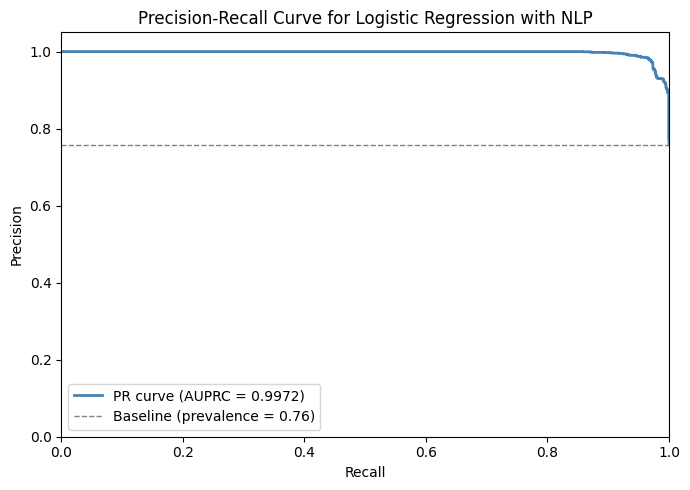

In [86]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_scores = model.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
auprc = average_precision_score(y_test, y_scores)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color="steelblue", lw=2, label=f"PR curve (AUPRC = {auprc:.4f})")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--", lw=1, label=f"Baseline (prevalence = {y_test.mean():.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve for Logistic Regression with NLP")
ax.legend(loc="lower left")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

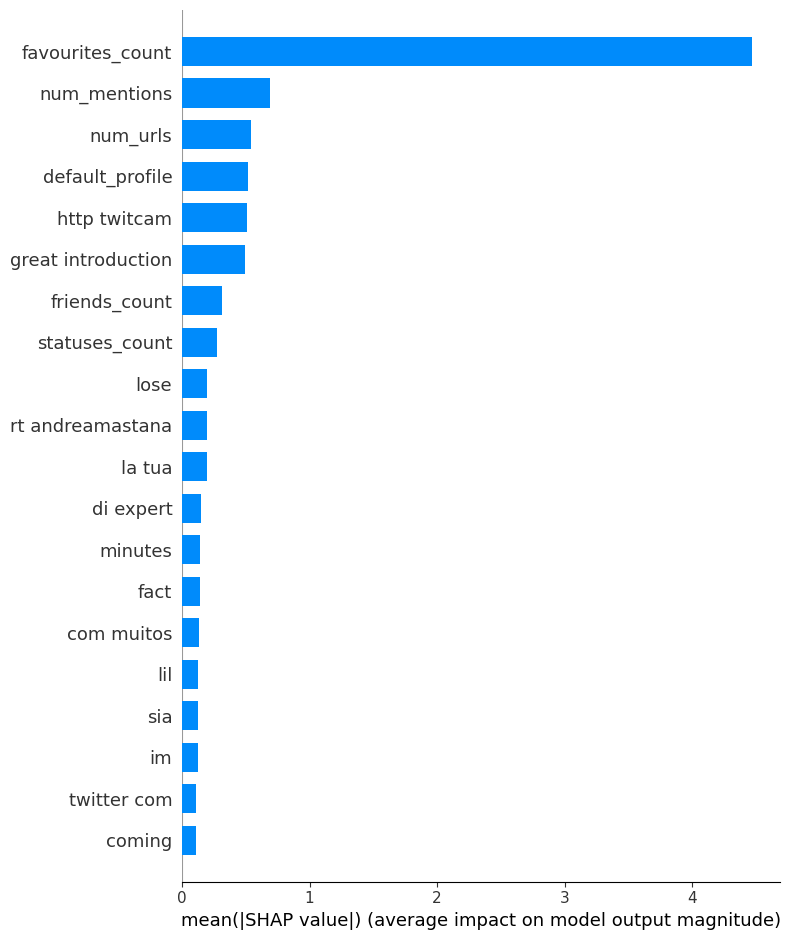

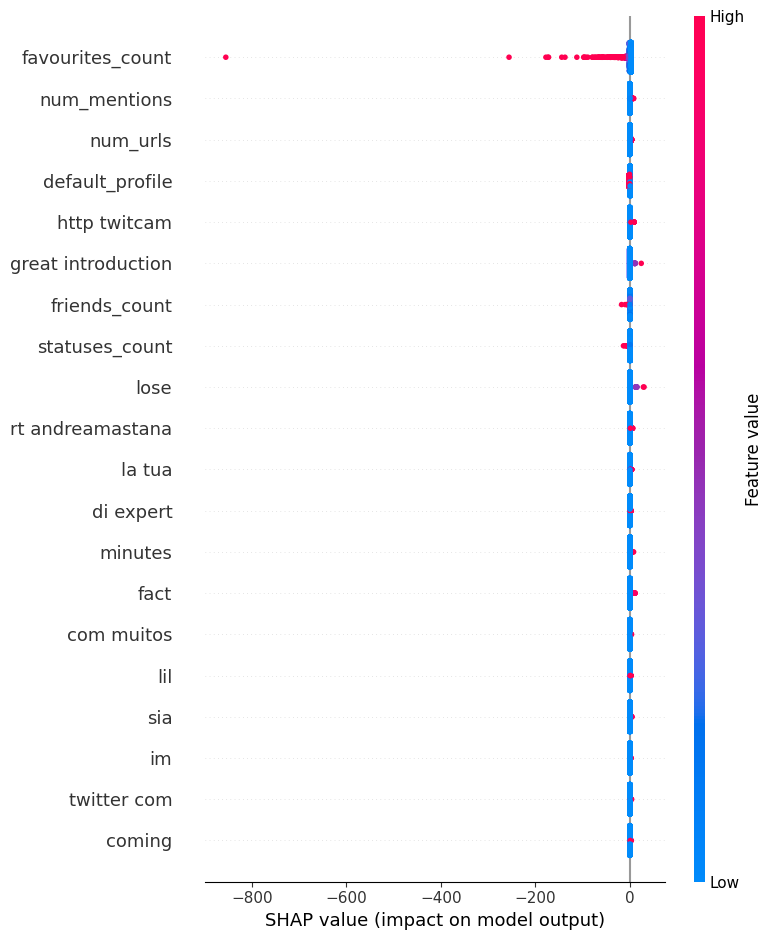

In [87]:
import shap

X_test_dense = X_test_scaled.toarray()

# Use LinearExplainer for linear models like LogisticRegression
explainer = shap.LinearExplainer(model, X_test_scaled)
shap_values = explainer.shap_values(X_test_dense)

shap.summary_plot(shap_values, X_test_dense, feature_names=all_feature_names, plot_type="bar")
shap.summary_plot(shap_values, X_test_dense, feature_names=all_feature_names)

## Run Order
1. Cell 2: imports and constants.
2. Cell 3: full data loading.
3. Cell 4: slicing and preprocessing.
4. Cell 5: training.
5. Cell 6: evaluation.

## Notes
- This notebook now loads all configured dataset files directly.
- If runtime or memory gets heavy, reduce loaded columns or process in chunks.